<a href="https://colab.research.google.com/github/Shashank18ram/Data-Science/blob/main/Movie%20Recommendation%20System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving tmdb_5000_credits.csv to tmdb_5000_credits (1).csv
Saving tmdb_5000_movies.csv to tmdb_5000_movies (1).csv


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, regexp_replace, concat_ws
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType


In [ ]:
spark = SparkSession.builder.appName("movie Recommender").getOrCreate()
print("Spark Started")

Spark Started


In [ ]:
movies = spark.read.csv("tmdb_5000_movies.csv", header=True, inferSchema=True)
credits = spark.read.csv("tmdb_5000_credits.csv", header=True, inferSchema=True)

movies.show(5)
credits.show(5)

+---------+-------------+--------------------+------------+--------------------+-----------------+--------------------+--------------------+--------------------+--------------------+--------------------+---------------+--------------------+--------------+--------------------+--------------+--------------------+---------------+--------------------+----------------+
|   budget|       genres|            homepage|          id|            keywords|original_language|      original_title|            overview|          popularity|production_companies|production_countries|   release_date|             revenue|       runtime|    spoken_languages|        status|             tagline|          title|        vote_average|      vote_count|
+---------+-------------+--------------------+------------+--------------------+-----------------+--------------------+--------------------+--------------------+--------------------+--------------------+---------------+--------------------+--------------+-----------

In [ ]:
movies = movies.join(credits, on="title", how="inner")

In [ ]:
def clean_column(column):
    return regexp_replace(column, r'[\[\]{}"]', '')

movies = movies.withColumn("genres", clean_column(col("genres"))) \
               .withColumn("keywords", clean_column(col("keywords"))) \
               .withColumn("cast", clean_column(col("cast"))) \
               .withColumn("crew", clean_column(col("crew")))

In [ ]:
movies = movies.fillna("")

movies = movies.withColumn(
    "tags",
    concat_ws(" ", "overview", "genres", "keywords", "cast", "crew")
)

movies.select("title", "tags").show(5, truncate=False)


+-----------------------------------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|title                                          |tags                                                                       

In [ ]:
tokenizer = Tokenizer(inputCol="tags", outputCol="words")
movies = tokenizer.transform(movies)

In [ ]:
remover = StopWordsRemover(inputCol="words", outputCol="filtered")
movies = remover.transform(movies)

In [ ]:
if "features" in movies.columns:
    movies = movies.drop("features")

cv = CountVectorizer(inputCol="filtered", outputCol="features", vocabSize=5000)
cv_model = cv.fit(movies)
movies = cv_model.transform(movies)

print("Features Ready")
movies.select("features").show(3, truncate=False)

Features Ready
+---------------------------------------------------------------------------------------+
|features                                                                               |
+---------------------------------------------------------------------------------------+
|(481,[0,1,2,10,13,14,33,299,378,390,446],[3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0])|
|(481,[0,1,2,6,10,13,14,43,141,211,313],[2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0])  |
|(481,[0,1,2,6,10,13,14,16,43,185],[2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0])           |
+---------------------------------------------------------------------------------------+
only showing top 3 rows


In [ ]:
def cosine_similarity(v1):
        v1 = v1.toArray()
        return float(np.dot(v1, target_array) / (np.linalg.norm(v1) * np.linalg.norm(target_array)))

cosine_udf = udf(cosine_similarity, DoubleType())
similarities = movies.withColumn(
        "similarity",
        cosine_udf(col("features"))
    )

In [ ]:
from IPython.display import display

def recommend(movie_name):

    movie_df = movies.filter(col("title") == movie_name).select("features").collect()

    if not movie_df:
        print("Movie not found")
        return

    target_vector = movie_df[0]["features"]
    target_array = target_vector.toArray()

    def cosine_similarity(v1):
        v1 = v1.toArray()
        return float(
            np.dot(v1, target_array) /
            (np.linalg.norm(v1) * np.linalg.norm(target_array))
        )

    cosine_udf = udf(cosine_similarity, DoubleType())

    similarities = movies.withColumn(
        "similarity",
        cosine_udf(col("features"))
    )

    result = similarities.orderBy(col("similarity").desc()) \
        .select("title", "similarity") \
        .limit(6) \
        .toPandas()

    print(f"\nTop recommendations for '{movie_name}':\n")

    display(result)

    plt.figure(figsize=(10,5))

    plt.bar(result["title"], result["similarity"])

    plt.xlabel("Movie Titles")
    plt.ylabel("Similarity Score")
    plt.title(f"Top Recommendations for {movie_name}")

    plt.xticks(rotation=45)

    plt.show()


Top recommendations for 'Delgo':



,title,similarity
0,Delgo,1.000000
1,Kevin Hart: Let Me Explain,0.699913
2,Woo,0.674453
3,Lisa Picard Is Famous,0.372081
4,Sparkler,0.346639
5,"The Book of Mormon Movie, Volume 1: The Journey",0.223054


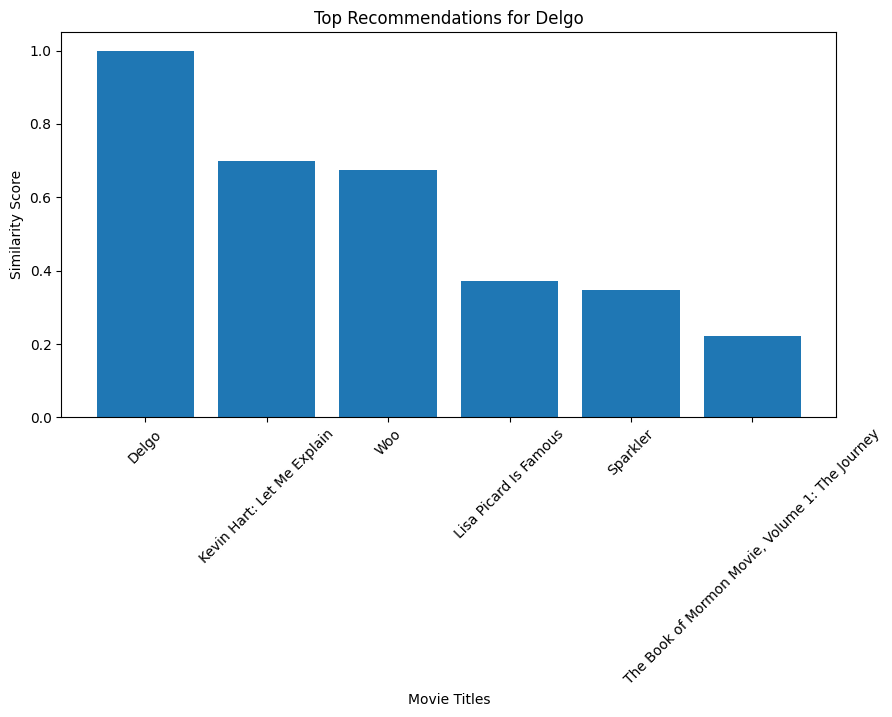

In [ ]:
recommend("Delgo")